# Profile Likelihood with ParmEst

After estimating parameter values, it is important to assess whether those
parameters are supported by the available experimental data. In other words,
we would like to understand not only which parameter values minimize the
objective function, but also how much confidence we should have in those
values.

Two related concepts are especially important in parameter estimation:

1. **Identifiability**

    A parameter is identifiable if it can, in principle, be uniquely determined
    from ideal noise-free data and the specified model structure.

    Structural identifiability is a property of the model itself. If a parameter
    is structurally unidentifiable, then no amount of additional data from the
    same experimental setup will allow that parameter to be uniquely estimated.

2. **Estimability**

    A parameter is estimable if it can be reliably estimated from the available
    finite, noisy experimental data.

    Practical estimability depends on the model, the data, the measurement noise,
    and the experimental design. A parameter may be structurally identifiable but
    still difficult to estimate in practice if the data are not sufficiently
    informative.

In this workshop, we focus on practical estimability, and using profile likelihood to assess if the selected model parameters can be estimated from available data. We assume that the model
has been specified and that experimental data are available, and we ask whether
the data contain enough information to estimate each parameter with reasonable
confidence.

### Import the necessary packages

In [1]:
import sys
import logging
import pandas as pd
import numpy as np

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_multistart_sampling,
    plot_profile_likelihood,
)

# set default number of states in the TCLab model
number_tclab_states = 2

### Load the experimental data

In [2]:
# load experimental data
if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = "../data/tclab_sine_test_5min_period.csv"
df = pd.read_csv(file)

# store in custom data class
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df["Time"].values,
    T1=df["T1"].values,
    u1=df["Q1"].values,
    P1=200,
    TS1_data=None,
    T2=df["T2"].values,
    u2=df["Q2"].values,
    P2=200,
    TS2_data=None,
    Tamb=df["T1"].values[0],
)

# set default number of states in the TCLab model
number_tclab_states = 2

In [3]:
# # Import parmest
import pyomo.contrib.parmest.parmest as parmest

# Set logging level to ERROR to suppress solver output and warnings from parmest
logging.basicConfig(level=logging.ERROR)

parmest_logger = logging.getLogger("pyomo.contrib.parmest.parmest")
parmest_logger.setLevel(logging.ERROR)

In [ ]:
# First, we define an Experiment object within parmest
TC_Lab_sine_exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states)

solver_options = {"linear_solver": "ma57", "max_iter": 1000}

In [ ]:
# Initialize ParmEst estimator with the TCLab model and experimental data
pest = parmest.Estimator(
    [TC_Lab_sine_exp], obj_function="SSE", tee=False, solver_options=solver_options
)


### Profile likelihood for estimability analysis

Profile likelihood is a useful tool for analyzing parameter estimability. The
main idea is to examine how much the objective function increases when one
parameter is fixed at values away from its estimated optimum, while all other
parameters are re-estimated.

Let $\hat{\boldsymbol{\theta}}$ be the parameter estimate obtained by solving

$$
   \hat{\boldsymbol{\theta}}
   =
   \arg\min_{\boldsymbol{\theta}}
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
$$

where $g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})$ is the parameter
estimation objective function.

For a parameter $\theta_j$, the profile likelihood is constructed by fixing
$\theta_j$ at a specified value and re-solving the parameter estimation problem
over the remaining parameters:

$$
   g_{\text{profile}}(\theta_j)
   =
   \min_{\boldsymbol{\theta}_{-j}}
   g(\boldsymbol{x}, \boldsymbol{y}; \theta_j, \boldsymbol{\theta}_{-j})
$$

where $\boldsymbol{\theta}_{-j}$ denotes the vector of all parameters except
$\theta_j$.

By repeating this calculation over a range of fixed values for $\theta_j$, we
obtain a profile that describes how sensitive the objective function is to
changes in that parameter.

---

### Interpreting Profile Likelihoods

The shape of the profile likelihood provides information about parameter
estimability.

If the profile likelihood increases sharply as $\theta_j$ moves away from its
estimated value, then the data strongly constrain that parameter. In this case,
$\theta_j$ is practically estimable.

If the profile likelihood is relatively flat over a wide range of values, then
many different values of $\theta_j$ provide similar agreement with the data. In
this case, $\theta_j$ may be practically non-estimable.

If the profile likelihood does not increase sufficiently in one or both
directions, then the data may only provide a one-sided bound or no meaningful
bound on the parameter.

Typical qualitative interpretations are:

- A **narrow profile** indicates that the parameter is well constrained by the data.
- A **wide profile** indicates that the parameter is weakly constrained by the data.
- A **flat profile** indicates that the parameter may be practically non-estimable.
- A **profile with a boundary** may indicate that the parameter is only bounded
  on one side or that the chosen parameter bounds affect the result.

In [ ]:
# Do profile likelihood estimation to construct confidence intervals for the parameters.
# This is a more robust method for constructing confidence intervals,
# as it does not rely on the assumption of normality in the parameter estimates.

# The best fit parameters are from the multistart estimation using Sobol sampling
best_obj_sobol = 53.773993
best_theta = {"Ua": 0.041705, 
                    "Ub": 0.017104, 
                    "inv_CpH": 0.170727, 
                    "inv_CpS": 3.130236}

best_theta_sobol = pd.DataFrame(
    best_theta, index=[0]
)


# Compute profile likelihood for both unknown parameters.
# Use a small grid for quick terminal runs.
profile_results = pest.profile_likelihood(
    profiled_theta=["Ua", "Ub", "inv_CpH", "inv_CpS"],
    obj_hat=best_obj_sobol,
    theta_hat=best_theta_sobol,
    n_grid=15,
    solver="ef_ipopt",
    warmstart="neighbor",
)

In [14]:
# Filter out runs that were not successful to focus on the successful ones for analysis
profiles = profile_results["profiles"]
profiles = profiles[profiles["success"] == True]
# Update the profile results to only include successful runs for
# subsequent analysis and plotting
profile_results["profiles"] = profiles

# Display a compact summary table
print("\nProfile results (first 5 rows):")
print(
    profiles[
        [
            "profiled_theta",
            "theta_value",
            "lr_stat",
            "status",
        ]
    ].head(5)
)


Profile results (first 5 rows):
  profiled_theta  theta_value       lr_stat   status
4             Ua     0.028572  1.132894e+05  optimal
5             Ua     0.035715  2.461208e+04  optimal
6             Ua     0.041705  9.379164e-13  optimal
7             Ua     0.042858  8.810234e+02  optimal
8             Ua     0.050001  3.867391e+04  optimal


Chi-squared threshold for 95% confidence interval: 3.8415


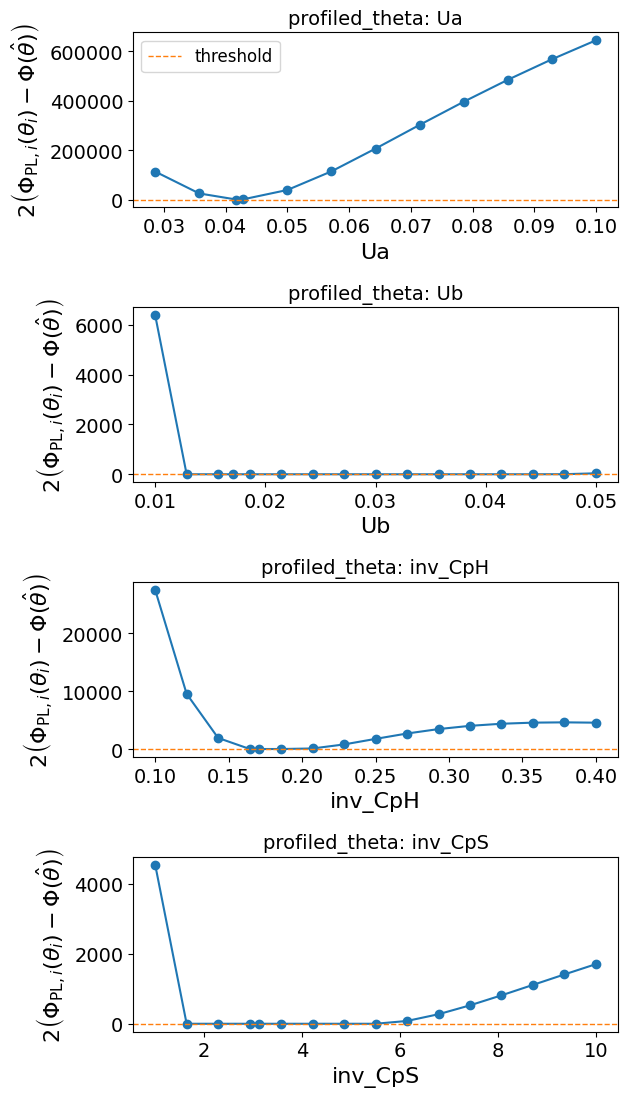

In [15]:
# Plot profile curves to visualize profile likelihood for each parameter.

# ylims = [(0, 100), (0, 100), (0, 100), (0, 100)]

fig, axes = plot_profile_likelihood(
    profile_results,
    alpha=0.95,
    # ylims=ylims
)

## Activity: Discuss profile likelihood results above with a neighbor

Take 2 minutes. From the profile likelihood results:

- Which parameter(s) are estimable?
- Which parameter(s) are inestimable?
- What are possible next steps to improve the estimability?

(Optional): Uncomment and adjust the xlims and ylims arguments to zoom in near the optimal region(s).
